In [1]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data = pd.read_csv('Amazon.com_Clusturing_Model.csv')

print(data.shape)
print(data)

(200, 5)
     Cus ID Sex  Age   Income  Rating
0    301219   M   23   306555      44
1    301220   F   26   306555      91
2    301221   F   24   326992       7
3    301222   M   28   326992      87
4    301223   F   38   347429      45
..      ...  ..  ...      ...     ...
195  301414   F   42  2452440      89
196  301415   F   54  2575062      32
197  301416   M   39  2575062      83
198  301417   M   39  2799869      21
199  301418   M   36  2799869      93

[200 rows x 5 columns]


In [3]:
data = pd.read_csv('Amazon.com_Clusturing_Model.csv')

print(data.shape)
print(data)

(200, 5)
     Cus ID Sex  Age   Income  Rating
0    301219   M   23   306555      44
1    301220   F   26   306555      91
2    301221   F   24   326992       7
3    301222   M   28   326992      87
4    301223   F   38   347429      45
..      ...  ..  ...      ...     ...
195  301414   F   42  2452440      89
196  301415   F   54  2575062      32
197  301416   M   39  2575062      83
198  301417   M   39  2799869      21
199  301418   M   36  2799869      93

[200 rows x 5 columns]


In [4]:
data.head()

,Cus ID,Sex,Age,Income,Rating
0,301219,M,23,306555,44
1,301220,F,26,306555,91
2,301221,F,24,326992,7
3,301222,M,28,326992,87
4,301223,F,38,347429,45


In [5]:
data.isnull().sum()

Cus ID    0
Sex       0
Age       0
Income    0
Rating    0
dtype: int64

In [6]:
x = data.iloc[:, [2, 4]].values

print(x.shape)
print(x[:5])

(200, 2)
[[23 44]
 [26 91]
 [24  7]
 [28 87]
 [38 45]]


In [7]:
wcss = []

In [8]:
for i in range(1, 11):

    model = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=21,
        n_init=10
    )

    model.fit(x)

    wcss.append(model.inertia_)

print(wcss)

[193670.0, 68009.54186795492, 46440.32740943268, 37710.028303450934, 30099.951385913446, 24102.49203939641, 19883.646250463476, 16864.99109164302, 14389.078840686394, 12861.01809447862]


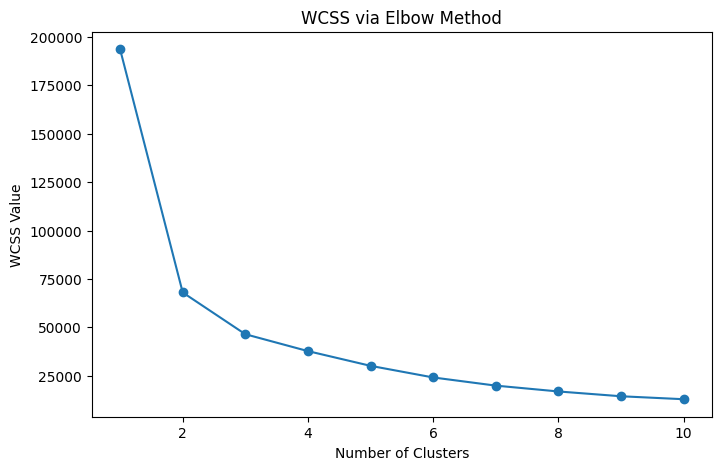

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), wcss, marker='o')

plt.title('WCSS via Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS Value')

plt.show()

In [10]:
model = KMeans(
    n_clusters=4,
    init='k-means++',
    random_state=42,
    n_init=10
)

In [11]:
model = KMeans(
    n_clusters=4,
    init='k-means++',
    random_state=42,
    n_init=10
)

In [12]:
y_means = model.fit_predict(x)

print("y_means:\n")
print(y_means)

y_means:

[3 1 0 1 3 3 0 0 1 3 3 3 2 0 3 3 2 0 3 0 0 0 0 0 0 3 0 0 3 2 2 3 0 3 3 2 1
 2 3 0 0 3 0 3 2 3 0 3 0 1 0 2 2 1 1 3 2 2 3 3 0 1 0 0 3 0 2 2 0 2 3 0 1 1
 3 3 0 0 0 0 1 0 0 3 1 1 1 3 3 2 3 0 1 0 2 1 1 2 3 0 0 0 3 3 0 2 1 0 1 0 0
 0 0 3 0 2 0 0 1 1 3 3 0 0 1 3 3 0 3 3 0 2 2 0 3 3 0 1 2 0 0 3 1 0 2 0 2 3
 1 0 2 3 2 2 0 0 0 0 0 2 3 1 1 3 0 1 3 0 0 0 1 2 0 0 0 3 2 2 2 0 2 0 0 2 3
 0 3 0 2 3 3 2 2 3 3 2 0 2 0 1]


In [13]:
y_means = model.fit_predict(x)

print("y_means:\n")
print(y_means)

y_means:

[3 1 0 1 3 3 0 0 1 3 3 3 2 0 3 3 2 0 3 0 0 0 0 0 0 3 0 0 3 2 2 3 0 3 3 2 1
 2 3 0 0 3 0 3 2 3 0 3 0 1 0 2 2 1 1 3 2 2 3 3 0 1 0 0 3 0 2 2 0 2 3 0 1 1
 3 3 0 0 0 0 1 0 0 3 1 1 1 3 3 2 3 0 1 0 2 1 1 2 3 0 0 0 3 3 0 2 1 0 1 0 0
 0 0 3 0 2 0 0 1 1 3 3 0 0 1 3 3 0 3 3 0 2 2 0 3 3 0 1 2 0 0 3 1 0 2 0 2 3
 1 0 2 3 2 2 0 0 0 0 0 2 3 1 1 3 0 1 3 0 0 0 1 2 0 0 0 3 2 2 2 0 2 0 0 2 3
 0 3 0 2 3 3 2 2 3 3 2 0 2 0 1]


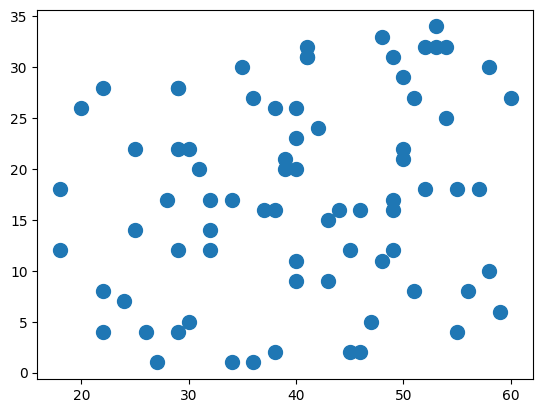

In [14]:
plt.scatter(
    x[y_means == 0, 0],
    x[y_means == 0, 1],
    s=100,
    label='Cluster 1'
)

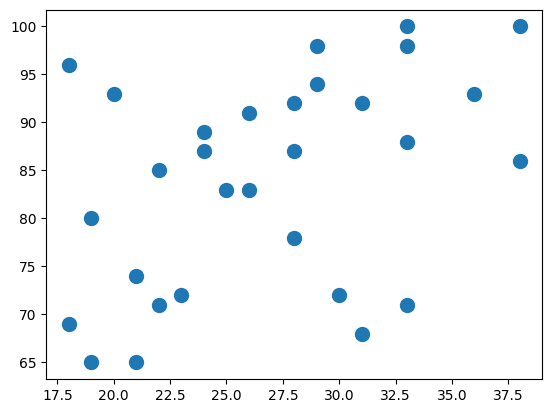

In [15]:
plt.scatter(
    x[y_means == 1, 0],
    x[y_means == 1, 1],
    s=100,
    label='Cluster 2'
)

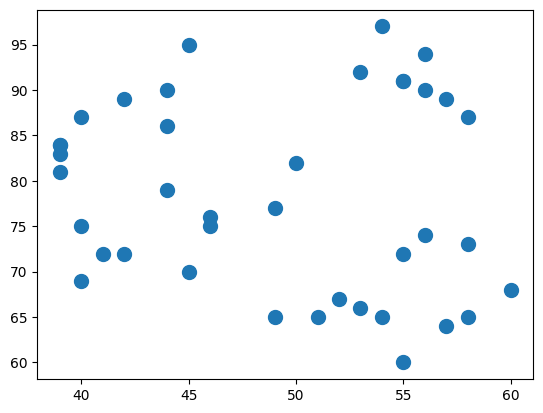

In [16]:
plt.scatter(
    x[y_means == 2, 0],
    x[y_means == 2, 1],
    s=100,
    label='Cluster 3'
)

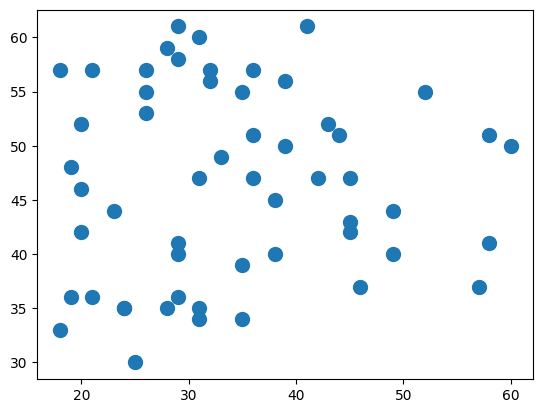

In [17]:
plt.scatter(
    x[y_means == 3, 0],
    x[y_means == 3, 1],
    s=100,
    label='Cluster 4'
)

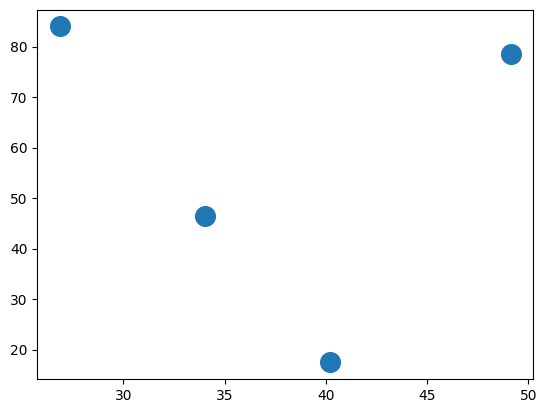

In [18]:
plt.scatter(
    model.cluster_centers_[:, 0],
    model.cluster_centers_[:, 1],
    s=200,
    label='Centroids'
)

C:\Users\kdeva\AppData\Local\Temp\ipykernel_10136\3138457489.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


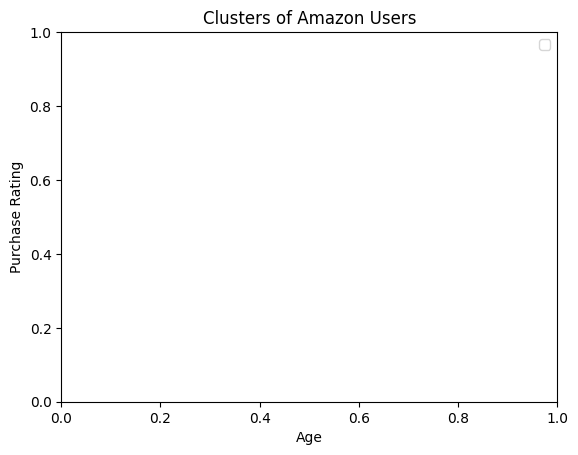

In [19]:
plt.title('Clusters of Amazon Users')
plt.xlabel('Age')
plt.ylabel('Purchase Rating')
plt.legend()

plt.show()